<a href="https://colab.research.google.com/github/juannMGC/Trabajo-de-Grado/blob/main/PropuestaTGRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

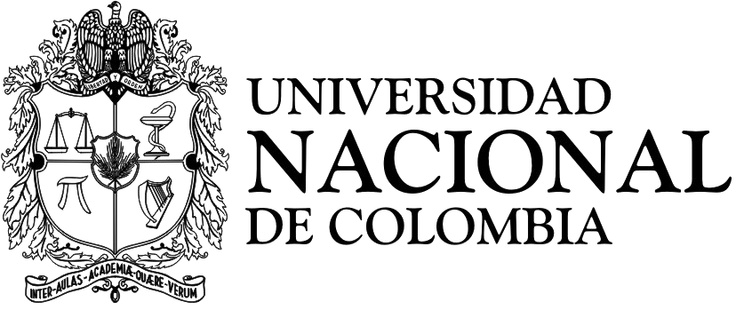
# **1. Proyecto Final: Machine Learning para predecir el impacto de la calidad del aire en la salud en Manizales.**

**Descripcion**

**Audiencia**

**Preguntas/Problema que buscamos resolver**

**Autor:** Juan Manuel Garcia Cifuentes

**Correo:** jugarciaci@unal.edu.co

# 2. Importación de datos y librerias

In [ ]:
# 1. MANIPULACIÓN DE DATOS
import pandas as pd
import numpy as np

# 2. VISUALIZACIÓN GRÁFICA
import matplotlib.pyplot as plt
import seaborn as sns

# 3. PREPROCESAMIENTO Y LIMPIEZA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 4. MODELOS DE APRENDIZAJE AUTOMÁTICO (Classifiers)
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# 5. MÉTRICAS DE EVALUACIÓN
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc
)

In [ ]:
df = pd.read_excel("BD_impacto_salud.xlsx")
df.head()

,Estacion_ICA,Estacion_PM10,Estacion_PM2_5,Estacion_SO2,Estacion_O3,Estacion_Temperatura,Estacion_Humedad,Estacion_VelocidadViento,Estacion_CasosRespiratorios,Estacion_IngresosHospitalariosR,...,Humedad,VelocidadViento,DiagnosticosRespiratorios,CasosRespiratorios,IngresosHospitalariosR,ConsultaHospitalariosR,DiagnosticosCardiovasculares,CasosCardiovasculares,IngresosHospitalariosC,ConsultaHospitalariosC
0,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,84.3,1.3,J00X - RINOFARINGITIS AGUDA (RESFRIADO COMUN),J158 - OTRAS NEUMONIAS BACTERIANAS,1.0,2.0,I051 - INSUFICIENCIA MITRAL REUMATICA,I10X - HIPERTENSION ESENCIAL (PRIMARIA),1.0,1.0
1,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,84.1,1.1,"J029 - FARINGITIS AGUDA, NO ESPECIFICADA","J159 - NEUMONIA BACTERIANA, NO ESPECIFICADA",1.0,1.0,I10X - HIPERTENSION ESENCIAL (PRIMARIA),I158 - OTROS TIPOS DE HIPERTENSION SECUNDARIA,1.0,7.0
2,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,79.3,1.2,"J039 - AMIGDALITIS AGUDA, NO ESPECIFICADA","J219 - BRONQUIOLITIS AGUDA, NO ESPECIFICADA",1.0,1.0,I158 - OTROS TIPOS DE HIPERTENSION SECUNDARIA,"I209 - ANGINA DE PECHO, NO ESPECIFICADA",1.0,1.0
3,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,79.6,0.6,"J159 - NEUMONIA BACTERIANA, NO ESPECIFICADA",J441 - ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA...,1.0,6.0,"I219 - INFARTO AGUDO DEL MIOCARDIO, SIN OTRA E...","I219 - INFARTO AGUDO DEL MIOCARDIO, SIN OTRA E...",1.0,7.0
4,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,92.5,1.0,"J189 - NEUMONIA, NO ESPECIFICADA",J449 - ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA...,2.0,3.0,I255 - CARDIOMIOPATIA ISQUEMICA,I500 - INSUFICIENCIA CARDIACA CONGESTIVA,2.0,4.0


In [ ]:
# Definición de colores y estilo
sns.set_palette("pastel")
sns.set_style("whitegrid")

plt.style.use('ggplot')
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

# 3. Análisis Exploratorio de Datos (EDA)

      3.1 Análisis Exploratorio de Datos (EDA)

### Creación de `ClaseImpactoSalud`

In [ ]:
def calculate_aqi(row):
    pollutants = ['PM2_5', 'PM10', 'SO2', 'O3']
    max_value = row[pollutants].max()

    if pd.isna(max_value):
        return 'Desconocido'
    if max_value <= 50:
        return 'Buena'
    elif max_value <= 100:
        return 'Moderada'
    elif max_value <= 150:
        return 'Dañina a grupos sensitivos'
    elif max_value <= 200:
        return 'Dañina a la salud'
    elif max_value <= 250:
        return 'Muy dañina a la salud'
    else:
        return 'Arriesgado'

df['ClaseImpactoSalud'] = df.apply(calculate_aqi, axis=1)

df.head()

,Estacion_ICA,Estacion_PM10,Estacion_PM2_5,Estacion_SO2,Estacion_O3,Estacion_Temperatura,Estacion_Humedad,Estacion_VelocidadViento,Estacion_CasosRespiratorios,Estacion_IngresosHospitalariosR,...,VelocidadViento,DiagnosticosRespiratorios,CasosRespiratorios,IngresosHospitalariosR,ConsultaHospitalariosR,DiagnosticosCardiovasculares,CasosCardiovasculares,IngresosHospitalariosC,ConsultaHospitalariosC,ClaseImpactoSalud
0,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,1.3,J00X - RINOFARINGITIS AGUDA (RESFRIADO COMUN),J158 - OTRAS NEUMONIAS BACTERIANAS,1.0,2.0,I051 - INSUFICIENCIA MITRAL REUMATICA,I10X - HIPERTENSION ESENCIAL (PRIMARIA),1.0,1.0,Buena
1,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,1.1,"J029 - FARINGITIS AGUDA, NO ESPECIFICADA","J159 - NEUMONIA BACTERIANA, NO ESPECIFICADA",1.0,1.0,I10X - HIPERTENSION ESENCIAL (PRIMARIA),I158 - OTROS TIPOS DE HIPERTENSION SECUNDARIA,1.0,7.0,Buena
2,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,1.2,"J039 - AMIGDALITIS AGUDA, NO ESPECIFICADA","J219 - BRONQUIOLITIS AGUDA, NO ESPECIFICADA",1.0,1.0,I158 - OTROS TIPOS DE HIPERTENSION SECUNDARIA,"I209 - ANGINA DE PECHO, NO ESPECIFICADA",1.0,1.0,Buena
3,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,0.6,"J159 - NEUMONIA BACTERIANA, NO ESPECIFICADA",J441 - ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA...,1.0,6.0,"I219 - INFARTO AGUDO DEL MIOCARDIO, SIN OTRA E...","I219 - INFARTO AGUDO DEL MIOCARDIO, SIN OTRA E...",1.0,7.0,Buena
4,Manizales,CATÓLICA (UCM),ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,ESTACIÓN GOBERNACIÓN,Manizales,Manizales,...,1.0,"J189 - NEUMONIA, NO ESPECIFICADA",J449 - ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA...,2.0,3.0,I255 - CARDIOMIOPATIA ISQUEMICA,I500 - INSUFICIENCIA CARDIACA CONGESTIVA,2.0,4.0,Buena


In [ ]:
# Tamaño del conjunto de datos
print("Filas, columnas: ", df.shape)

# Nombres de las variables
print("\nNombres de las variables: \n", df.columns)

# Tipo de datos de cada variable
print("\nTipos de datos: \n", df.dtypes)

# Verificar la presencia de valores faltantes
print("\nValores faltantes: \n", df.isnull().sum())

# Estadísticas descriptivas de las variables numéricas
print("\nEstadísticas descriptivas: \n", df.describe(include=[np.number]))

# Frecuencia de valores únicos en las variables categóricas
for col in df.select_dtypes(include=['object']).columns:
    print("\nFrecuencia de valores únicos de", col)
    print(df[col].value_counts())

Filas, columnas:  (65913, 41)

Nombres de las variables: 
 Index(['Estacion_ICA', 'Estacion_PM10', 'Estacion_PM2_5', 'Estacion_SO2',
       'Estacion_O3', 'Estacion_Temperatura', 'Estacion_Humedad',
       'Estacion_VelocidadViento', 'Estacion_CasosRespiratorios',
       'Estacion_IngresosHospitalariosR', 'Estacion_CasosCardiovasculares',
       'Estacion_IngresosHospitalariosC', 'Fecha_ICA', 'Fecha_PM10',
       'Fecha_PM2_5', 'Fecha_SO2', 'Fecha_O3', 'Fecha_Temperatura',
       'Fecha_Humedad', 'Fecha_VelocidadViento', 'Fecha_CasosRespiratorios',
       'Fecha_IngresosHospitalariosR', 'Fecha_CasosCardiovasculares',
       'Fecha_IngresosHospitalariosC', 'ICA', 'PM10', 'PM2_5', 'SO2', 'O3',
       'Temperatura', 'Humedad', 'VelocidadViento',
       'DiagnosticosRespiratorios', 'CasosRespiratorios',
       'IngresosHospitalariosR', 'ConsultaHospitalariosR',
       'DiagnosticosCardiovasculares', 'CasosCardiovasculares',
       'IngresosHospitalariosC', 'ConsultaHospitalariosC',
       

      3.2 Análisis de valores atípicos

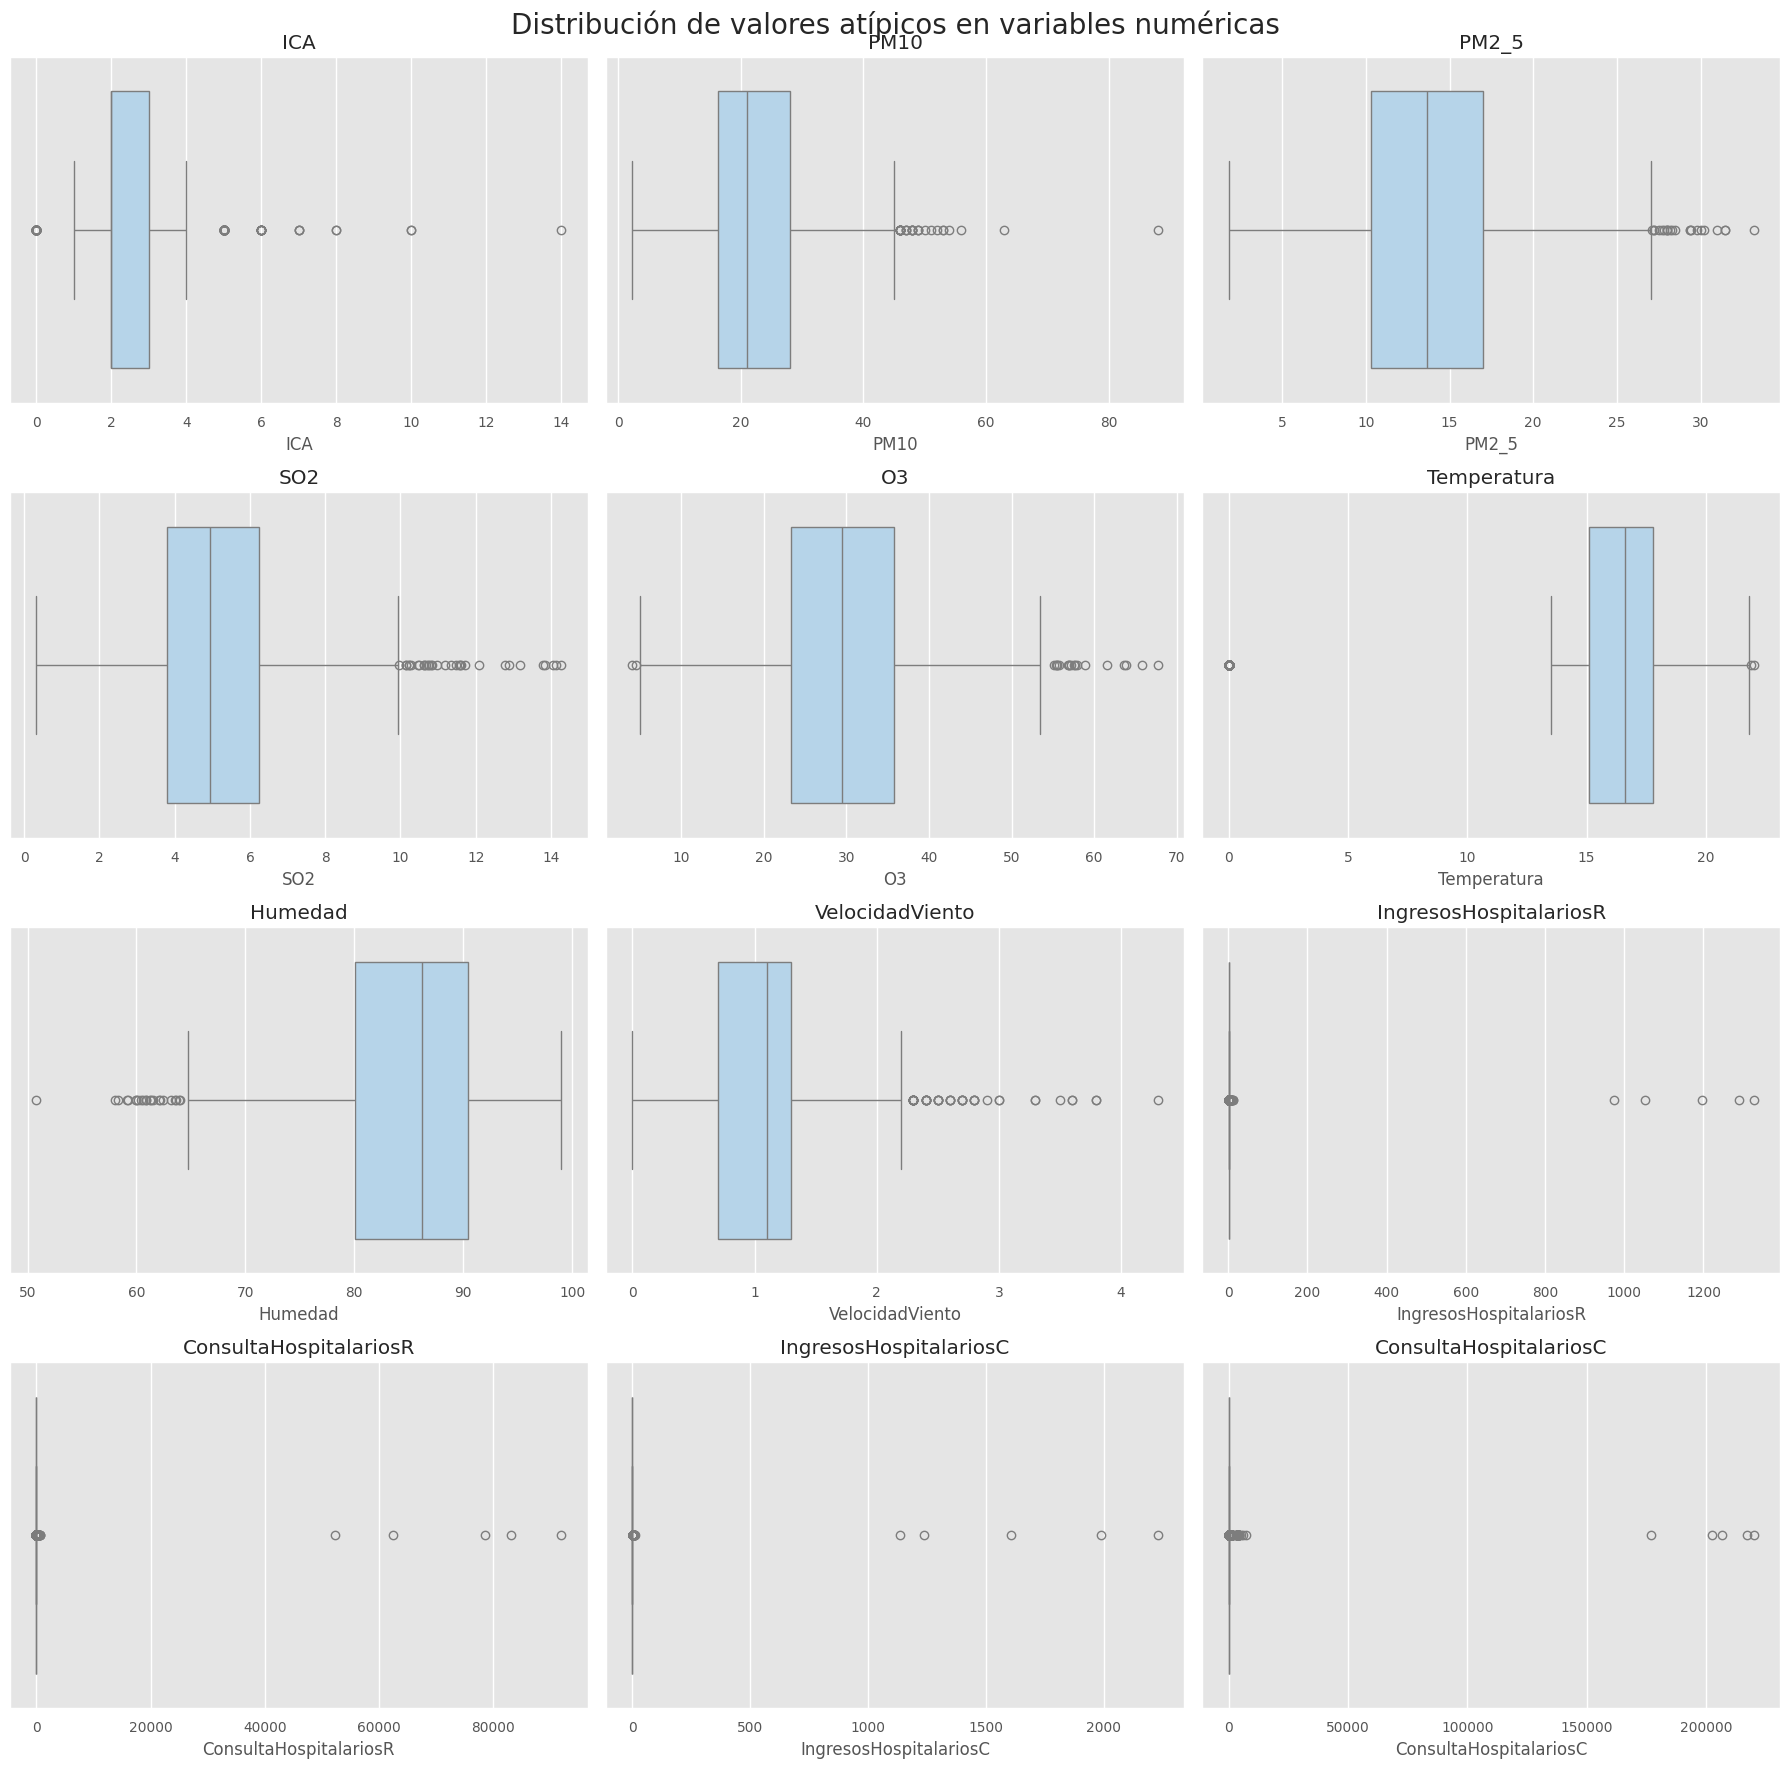

In [ ]:
# Definición de columnas numéricas
num_cols = [
    'ICA', 'PM10', 'PM2_5', 'SO2', 'O3',
    'Temperatura', 'Humedad', 'VelocidadViento',
    'IngresosHospitalariosR', 'ConsultaHospitalariosR',
    'IngresosHospitalariosC', 'ConsultaHospitalariosC'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Graficar boxplots
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(18, 18))
fig.suptitle('Distribución de valores atípicos en variables numéricas', fontsize=20)

axs = axs.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axs[i], color='#AED6F1')
    axs[i].set_title(col)

plt.tight_layout()
plt.show()


      3.3 Distribución de variables categóricas

/tmp/ipython-input-2667633505.py:22: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


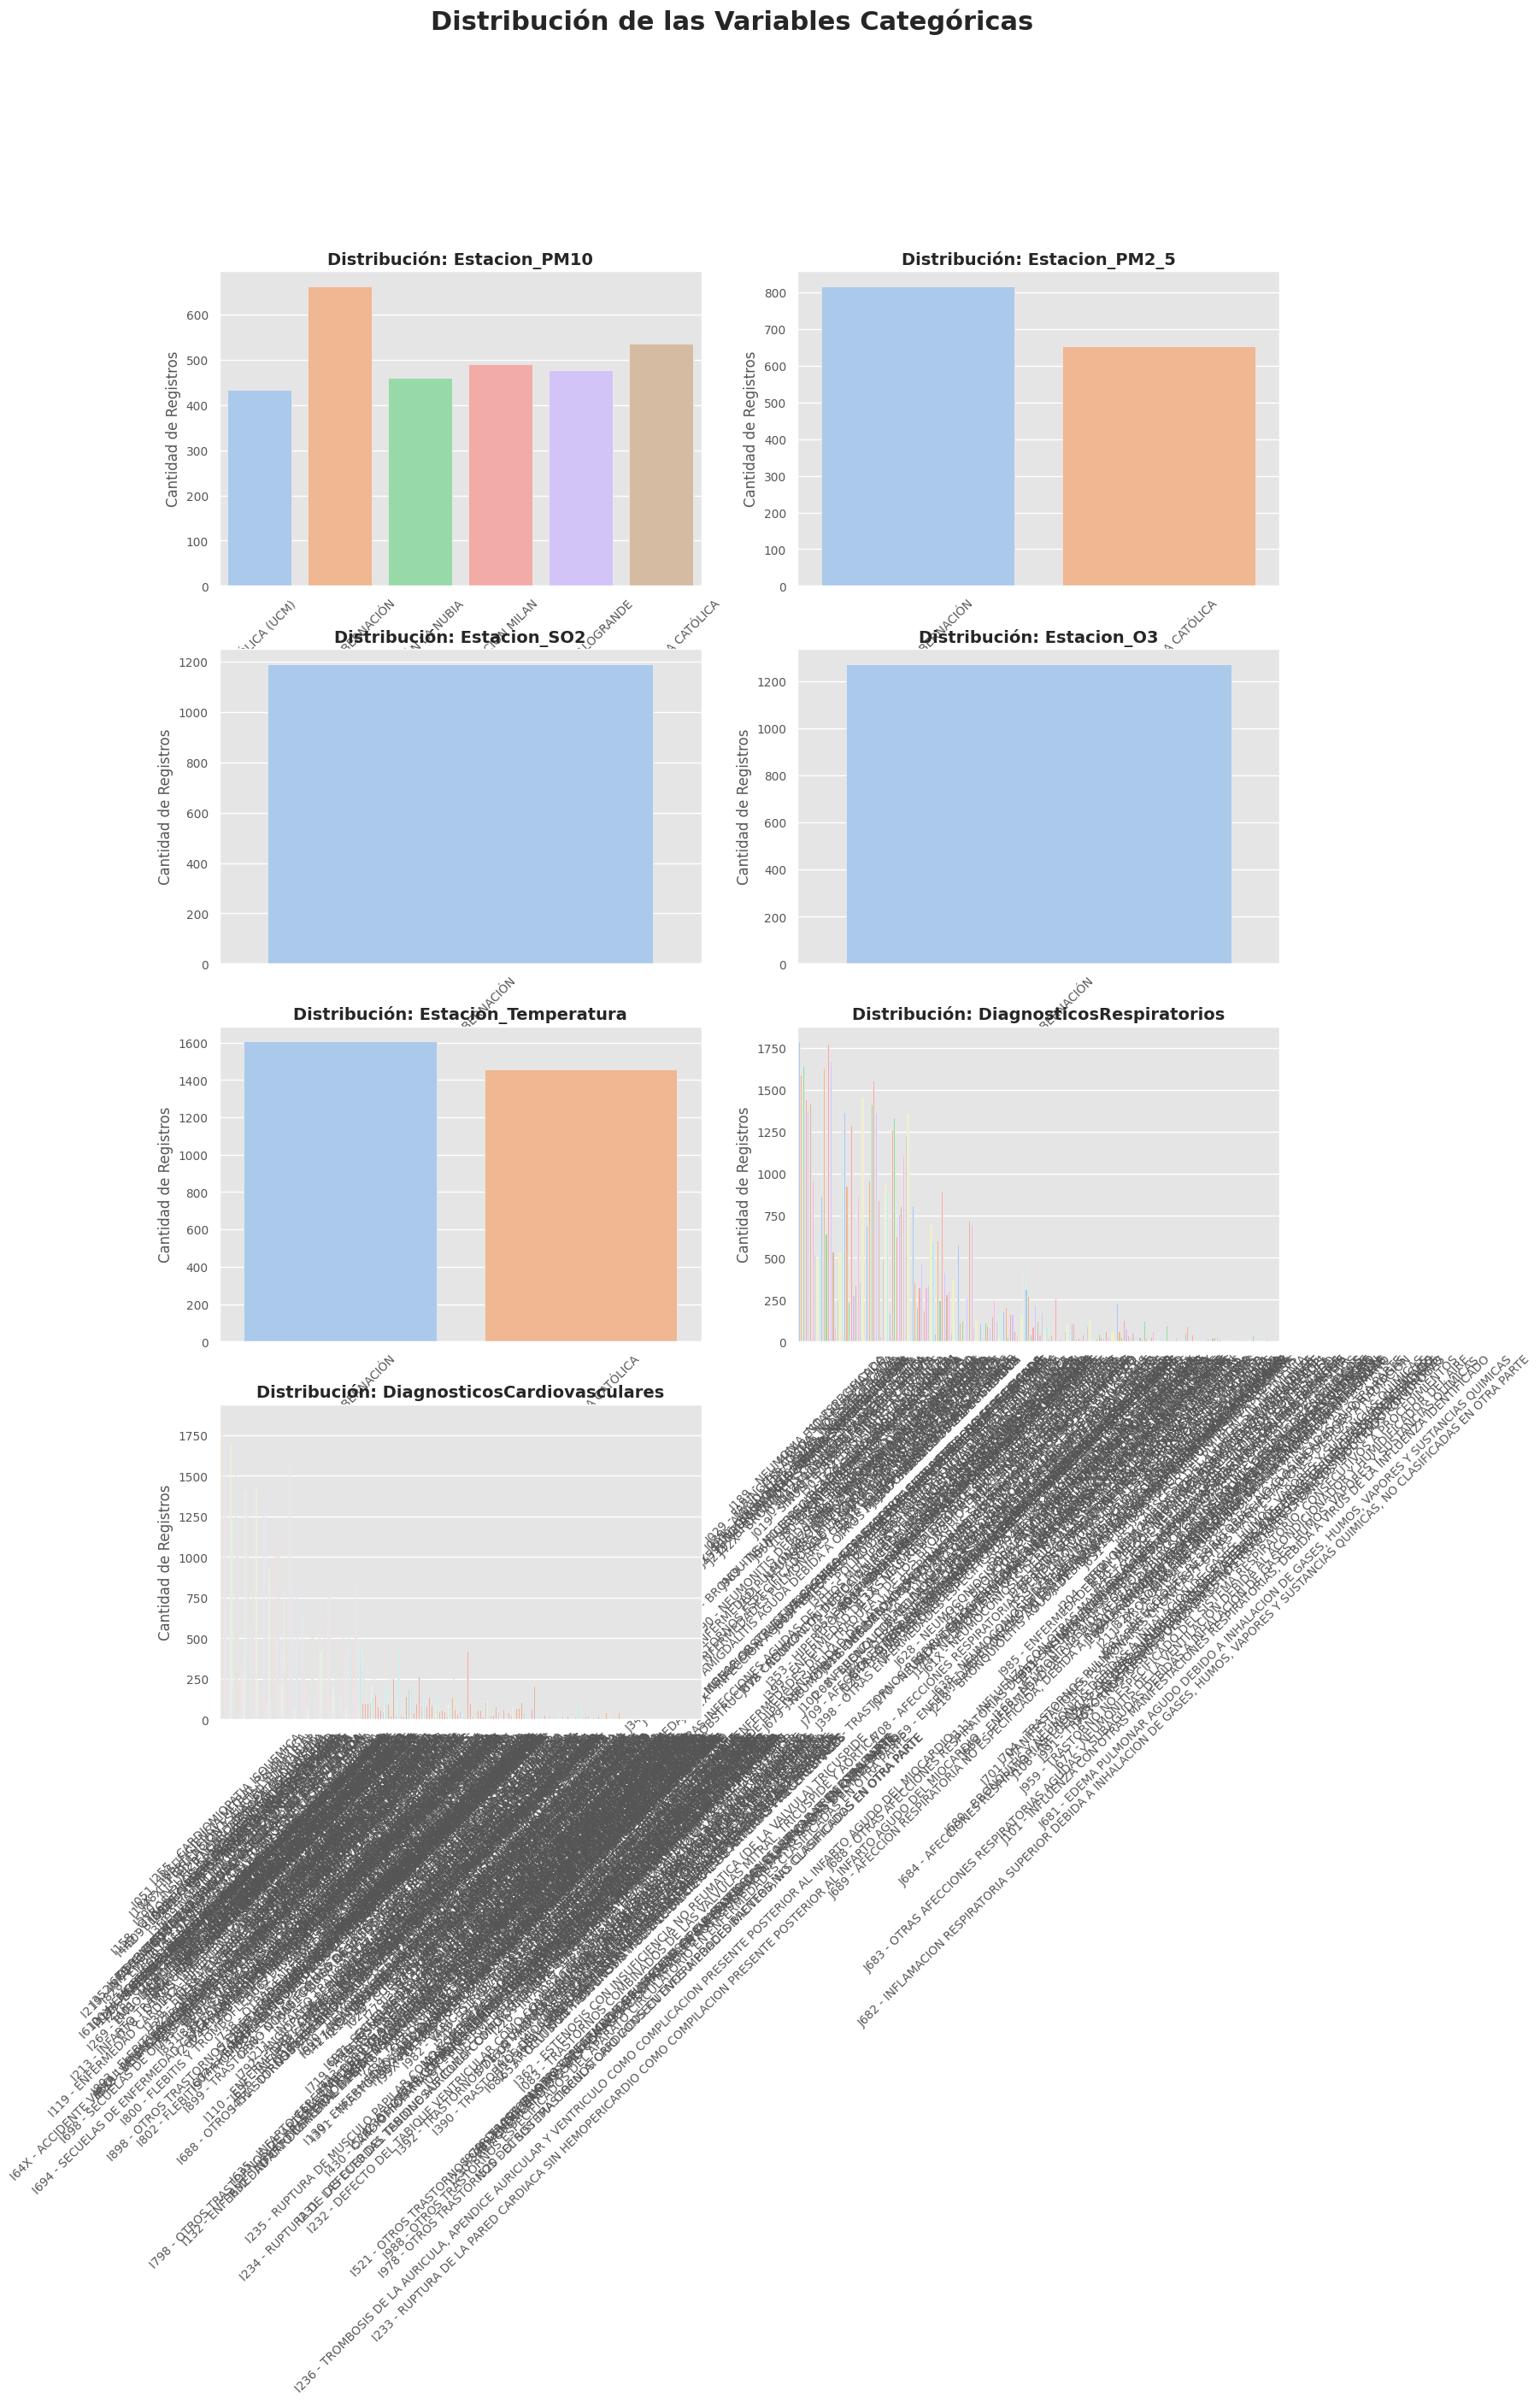

In [ ]:
# Variables categóricas
cat_cols = [
    'Estacion_PM10', 'Estacion_PM2_5', 'Estacion_SO2',
    'Estacion_O3', 'Estacion_Temperatura',
    'DiagnosticosRespiratorios', 'DiagnosticosCardiovasculares'
]

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
fig.suptitle('Distribución de las Variables Categóricas', fontsize=22, fontweight='bold', y=1.02)
axs = axs.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axs[i], hue=col, palette='pastel', legend=False)
    axs[i].set_title(f'Distribución: {col}', fontsize=14, fontweight='semibold')
    axs[i].set_xlabel('')
    axs[i].set_ylabel('Cantidad de Registros', fontsize=12)
    axs[i].tick_params(axis='x', rotation=45)

if len(cat_cols) < len(axs):
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()

      3.4 Relación entre las variables categóricas y el impacto en la salud

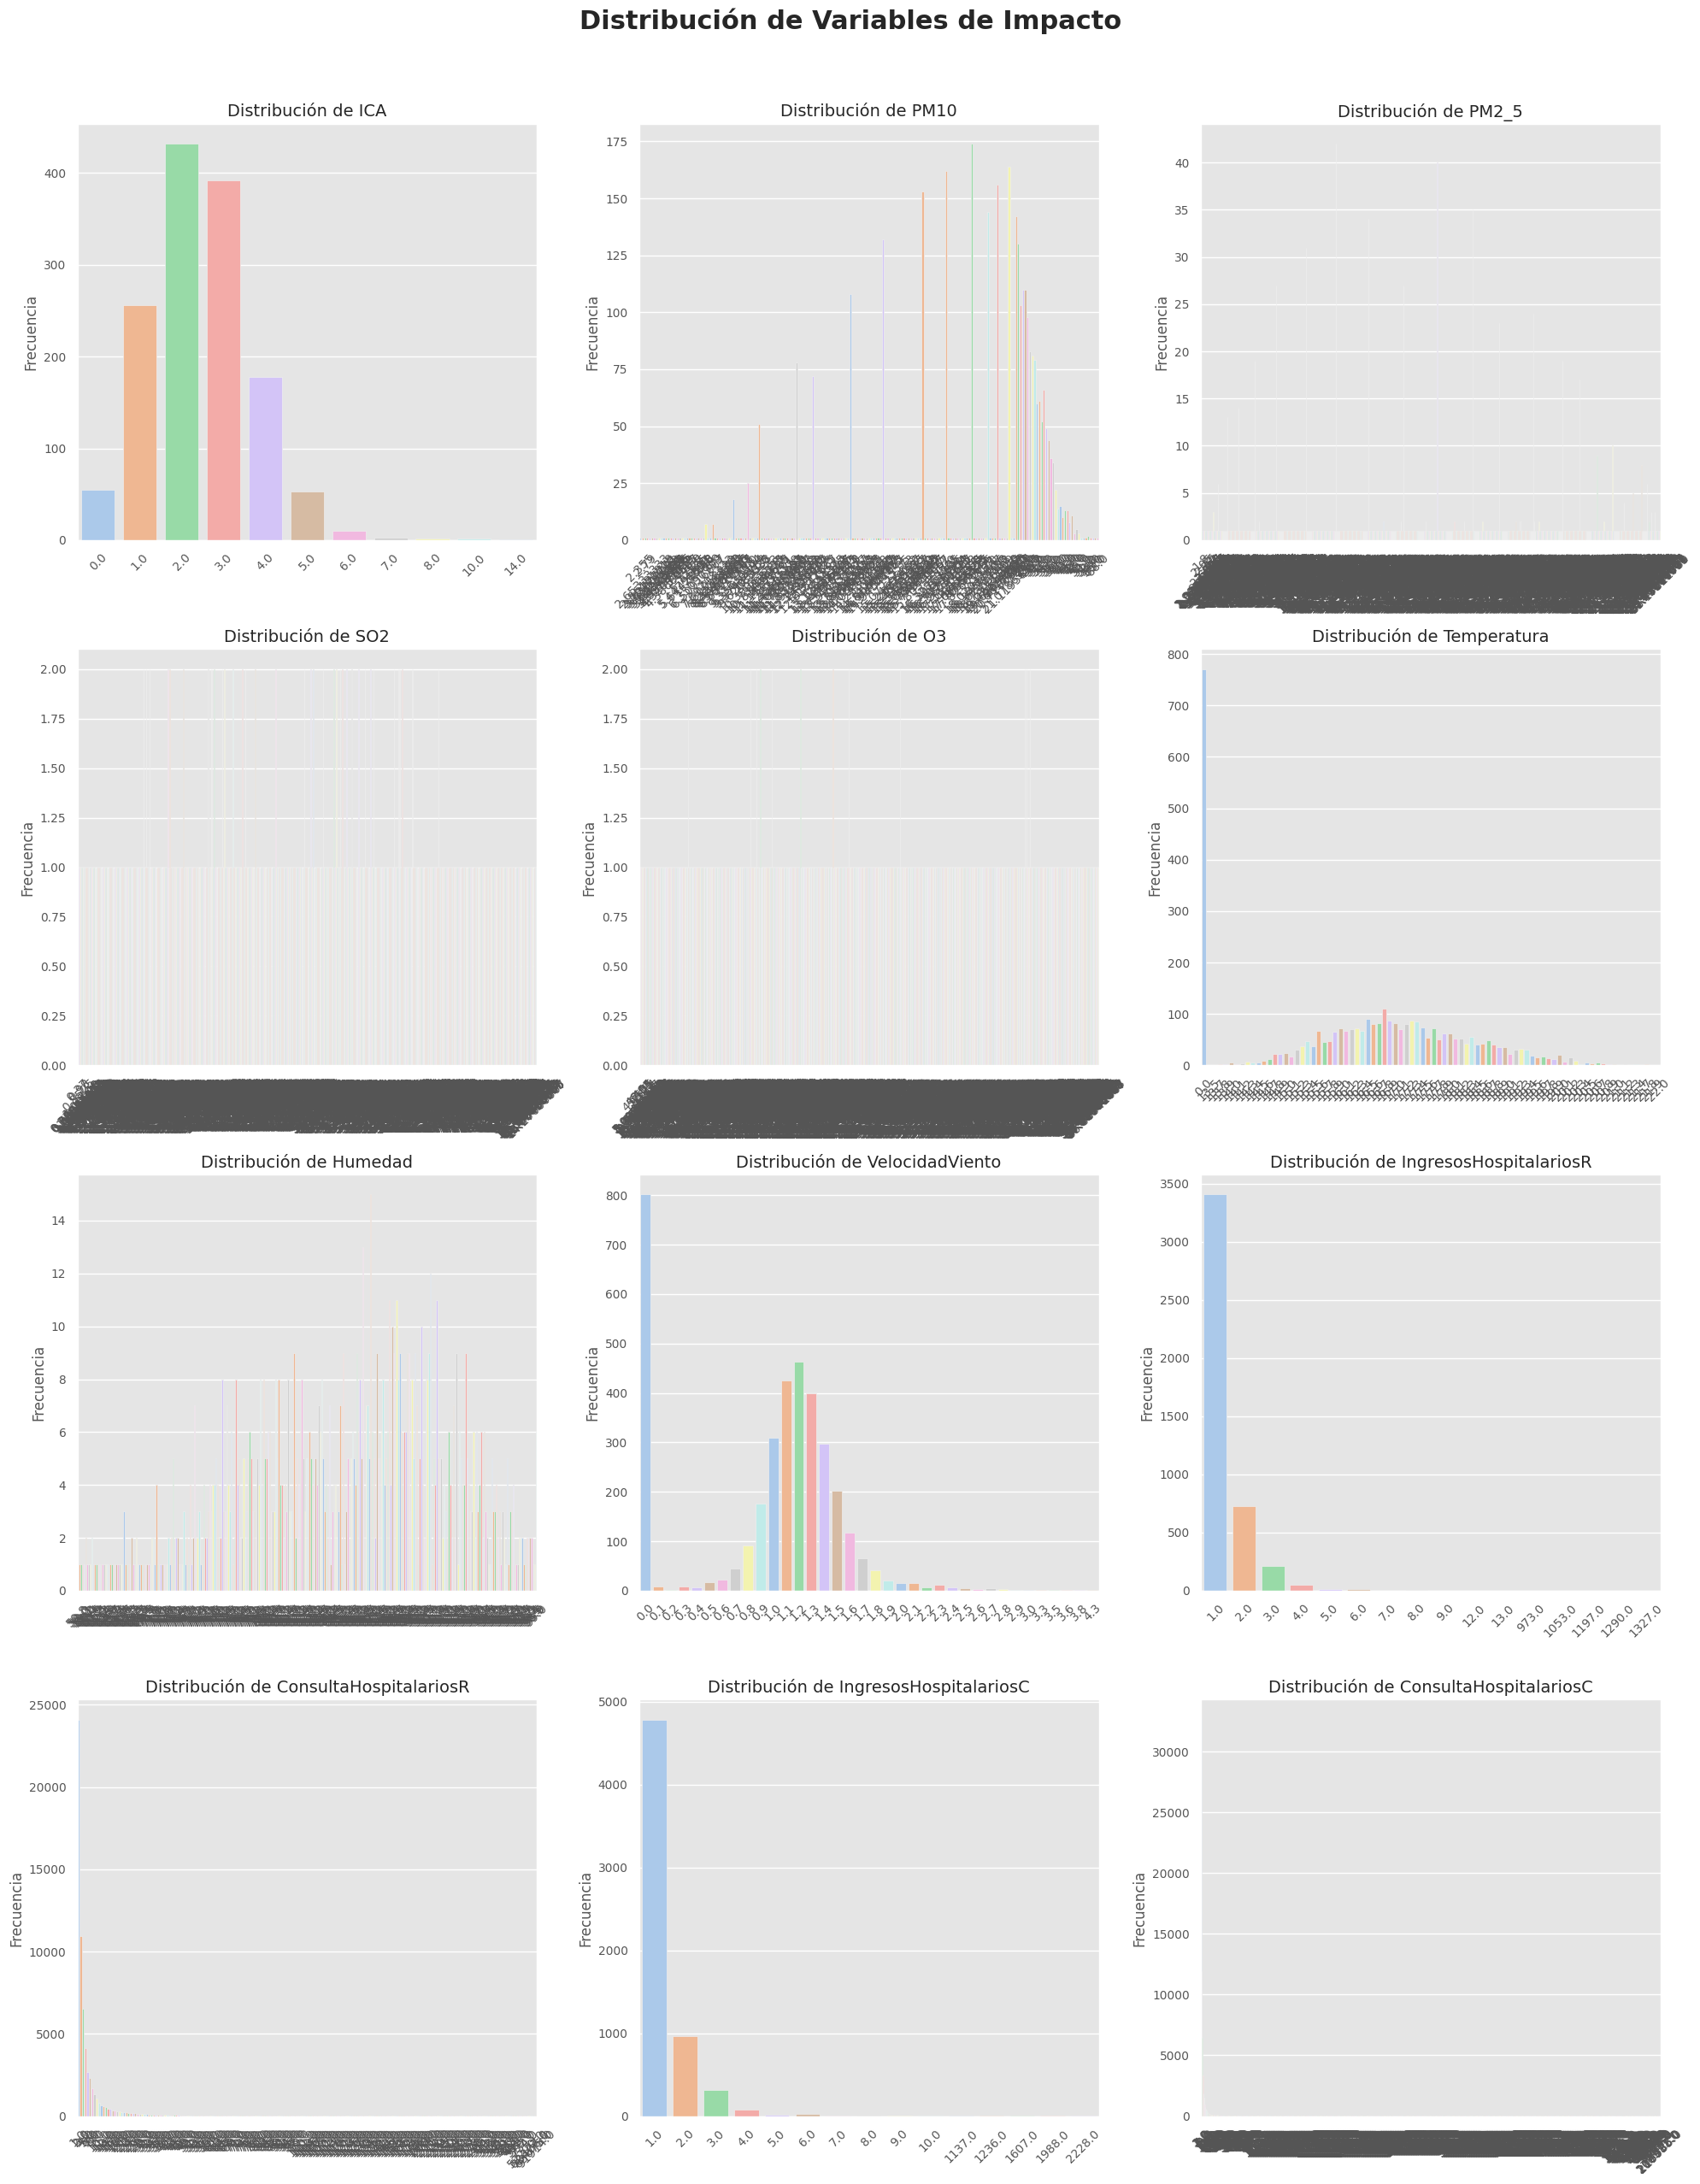

In [ ]:
cat_cols_rel = [
    'ICA', 'PM10', 'PM2_5', 'SO2', 'O3',
    'Temperatura', 'Humedad', 'VelocidadViento',
    'IngresosHospitalariosR', 'ConsultaHospitalariosR',
    'IngresosHospitalariosC', 'ConsultaHospitalariosC'
]

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(20, 25))
fig.suptitle('Distribución de Variables de Impacto', fontsize=22, fontweight='bold', y=1.02)

axs = axs.flatten()

for i, col in enumerate(cat_cols_rel):
    sns.countplot(x=col, data=df, ax=axs[i], hue=col, palette='pastel', legend=False)
    axs[i].set_title(f'Distribución de {col}', fontsize=14)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('Frecuencia')
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipython-input-3428199505.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


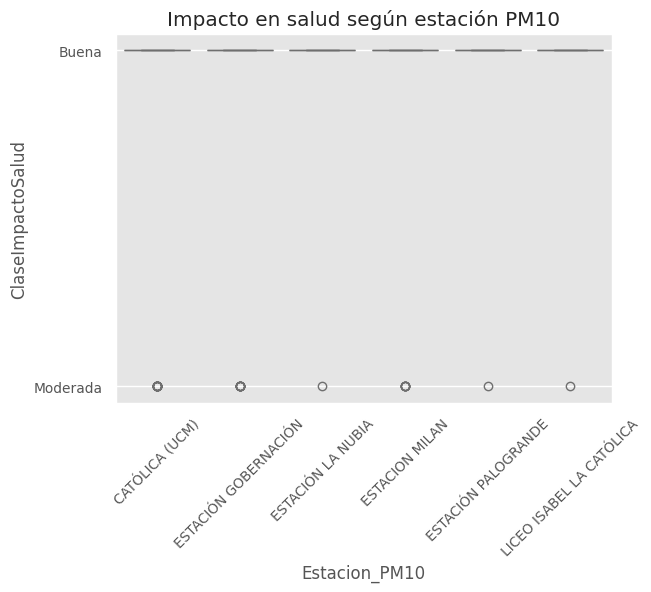

In [ ]:
sns.boxplot(
    x='Estacion_PM10',
    y='ClaseImpactoSalud',
    data=df,
    palette='pastel'
)
plt.title('Impacto en salud según estación PM10')
plt.xticks(rotation=45)
plt.show()


      3.5 Distribución de variables numéricas

Estadísticas descriptivas (Media) 
----------------------------------
Media de PM10: 22.5299
Media de PM2_5: 13.989
Media de SO2: 5.1493
Media de O3: 29.7751


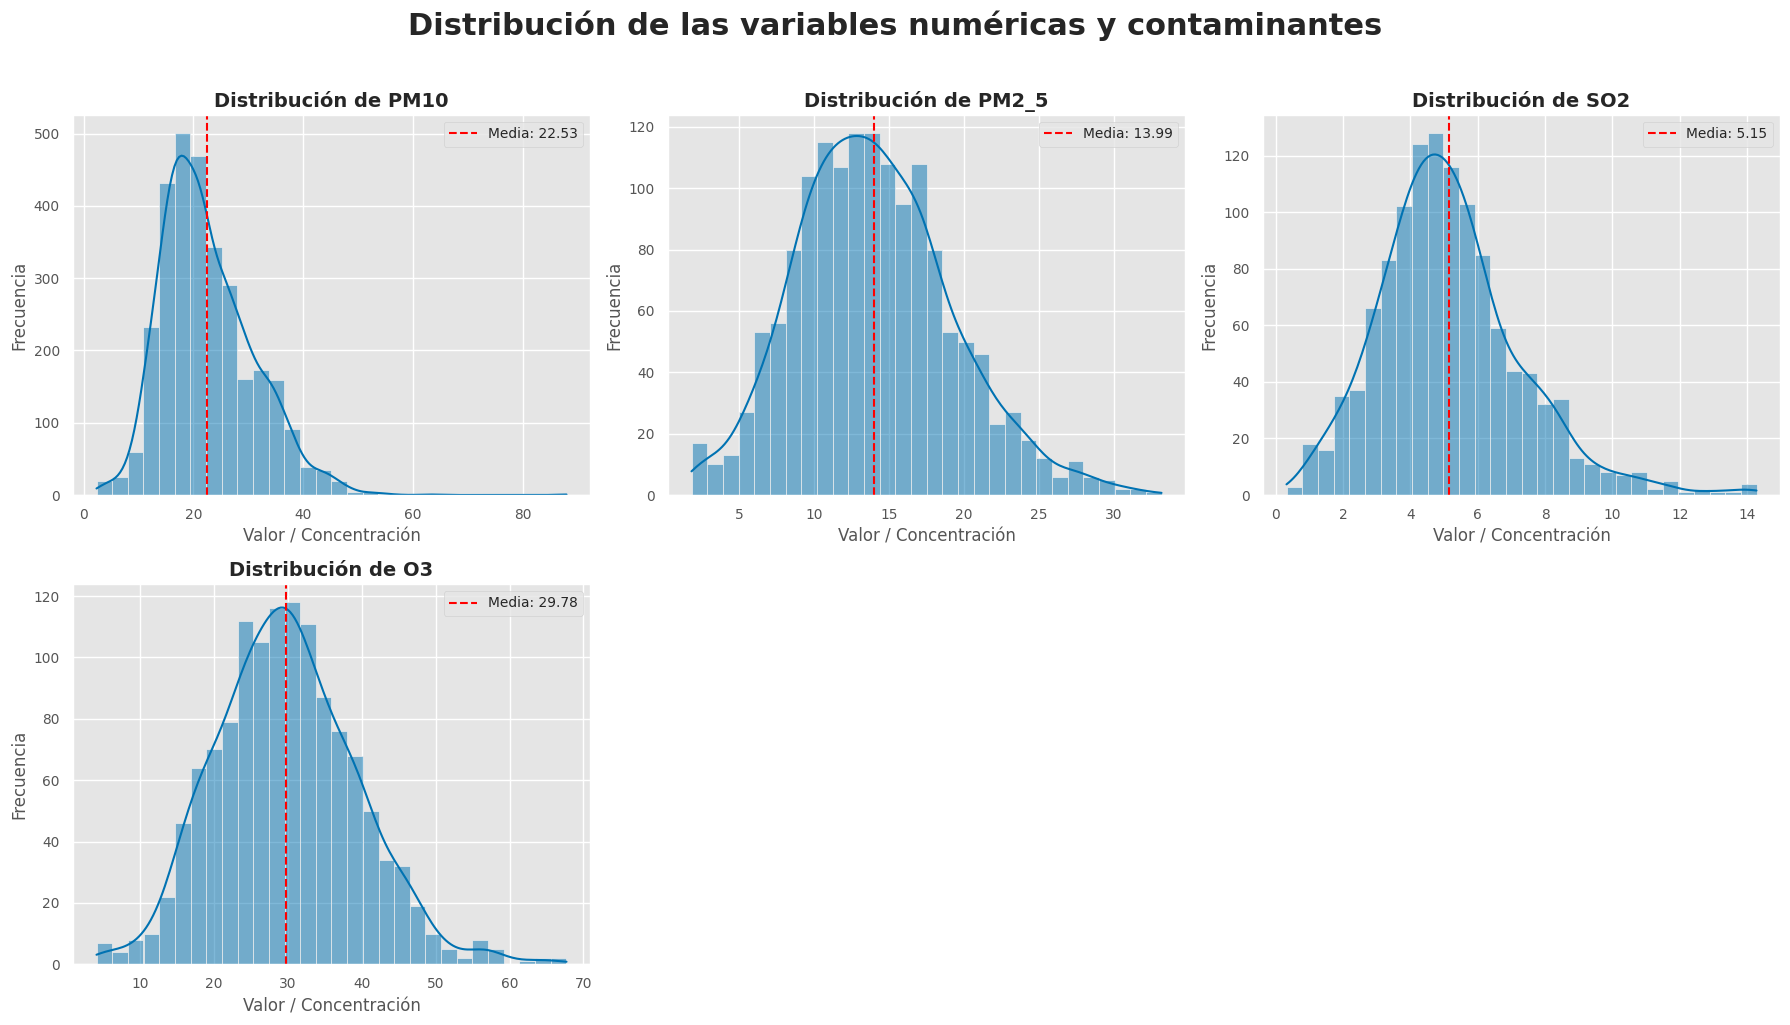

In [ ]:
# Variables numéricas
num_cols = ['PM10', 'PM2_5', 'SO2', 'O3']

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('Distribución de las variables numéricas y contaminantes', fontsize=22, fontweight='bold', y=1.02)
axs = axs.flatten()

print('Estadísticas descriptivas (Media) \n----------------------------------')

for i, col in enumerate(num_cols):
    if col in df.columns:
        sns.histplot(x=col, data=df, ax=axs[i], kde=True, color='#0072B2', bins=30)
        axs[i].set_title(f'Distribución de {col}', fontsize=14, fontweight='semibold')
        axs[i].set_xlabel('Valor / Concentración')
        axs[i].set_ylabel('Frecuencia')
        media = df[col].mean()
        print(f'Media de {col}: {round(media, 4)}')
        axs[i].axvline(media, color='red', linestyle='--', label=f'Media: {round(media, 2)}')
        axs[i].legend()
    else:
        axs[i].set_title(f'Columna {col} no encontrada', color='red')
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

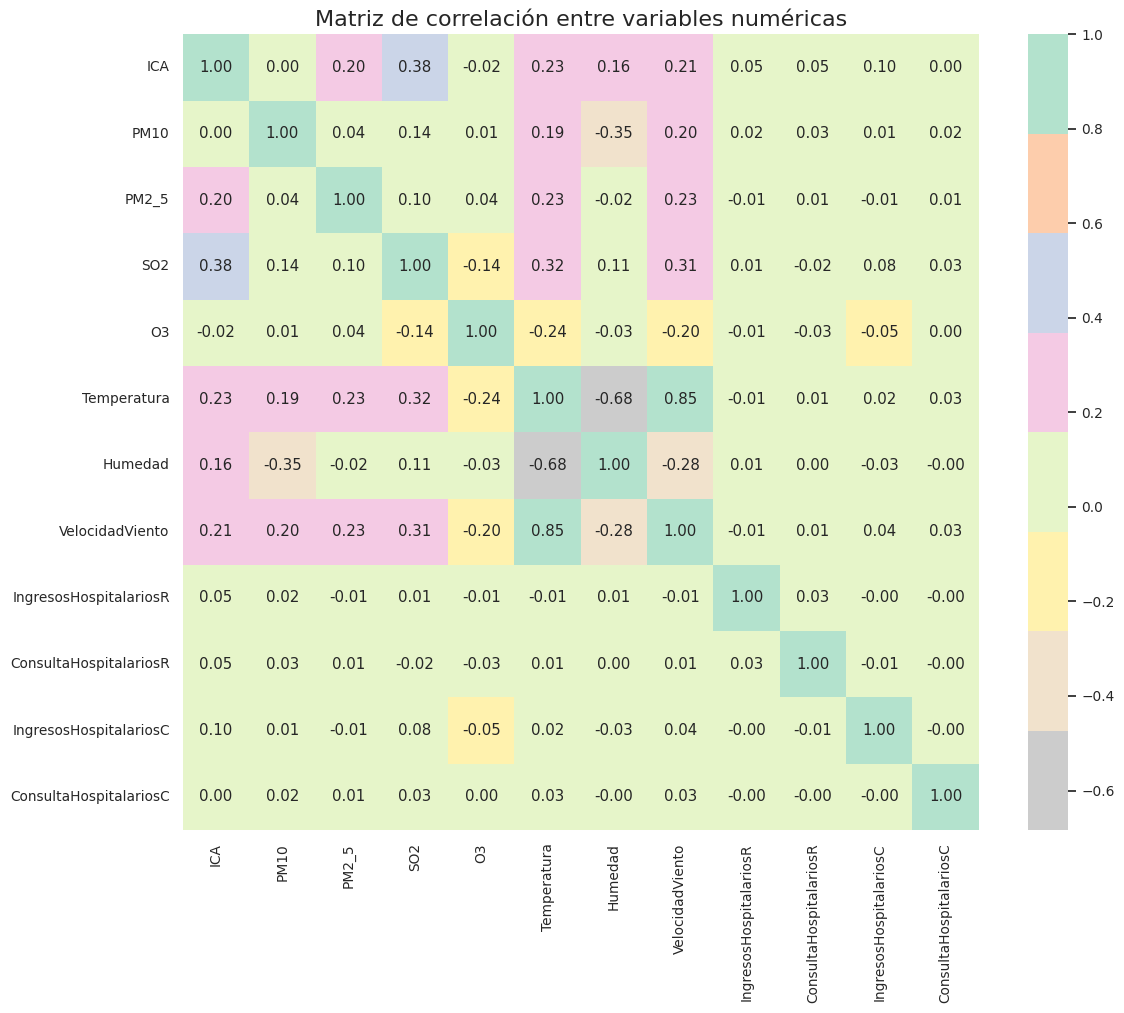

In [ ]:
# Correlación entre variables numéricas
df_num = df.select_dtypes(include='number')
corr_matrix = df_num.corr()

plt.figure(figsize=(12, 10))
sns.set(font_scale=0.9)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='Pastel2_r',
    square=True
)

plt.title('Matriz de correlación entre variables numéricas', fontsize=16)
plt.tight_layout()
plt.show()


      3.6 Relación entre las variables numéricas y el impacto en la salud

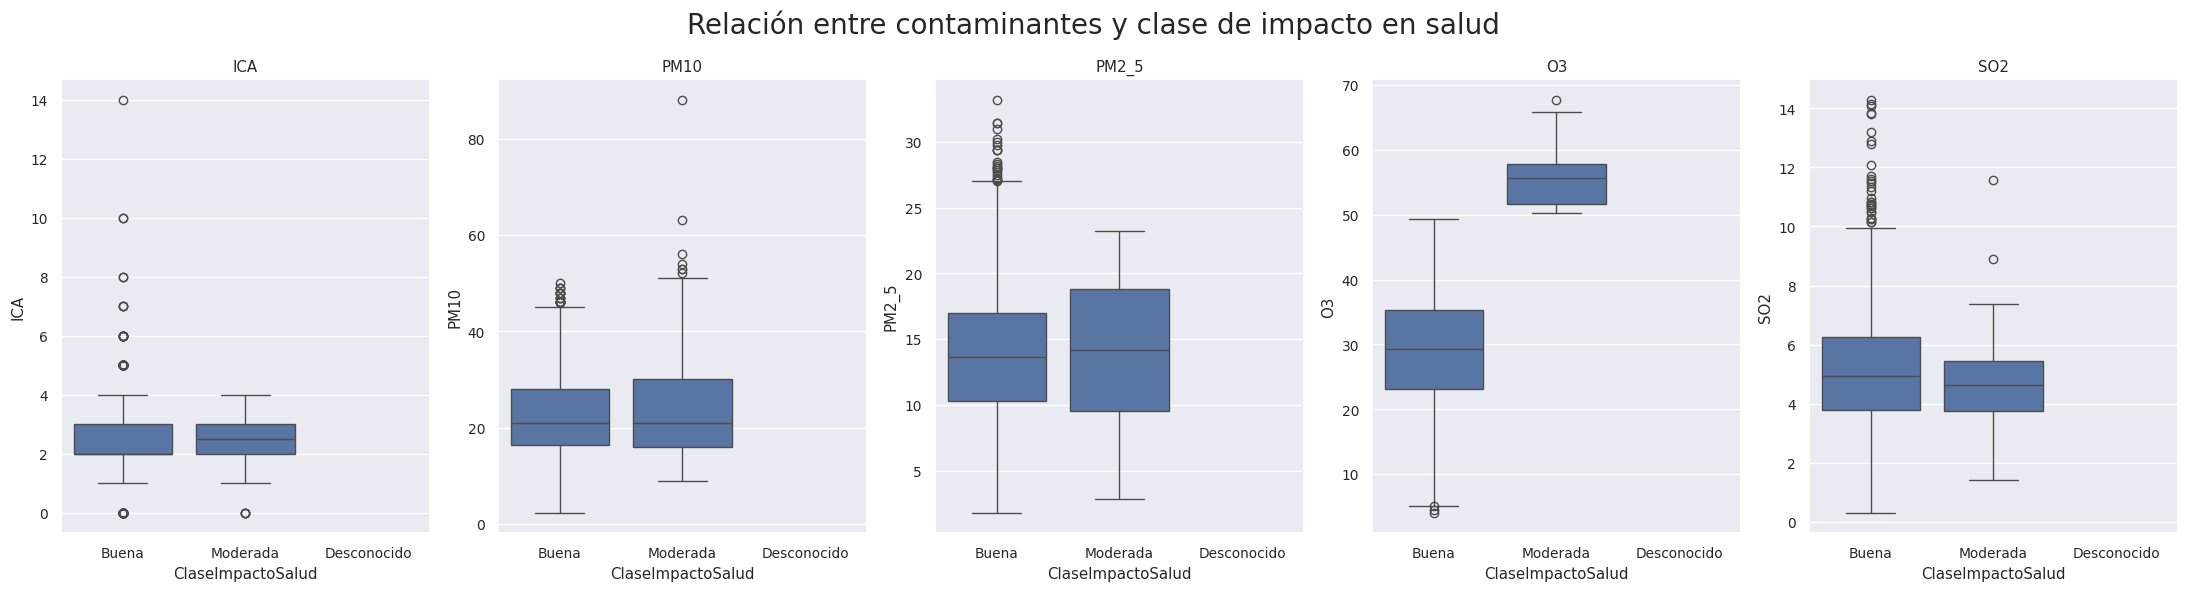

In [ ]:
impact_cols = ['ICA', 'PM10', 'PM2_5', 'O3', 'SO2']

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(22, 6))
fig.suptitle('Relación entre contaminantes y clase de impacto en salud', fontsize=20)

for i, col in enumerate(impact_cols):
    sns.boxplot(x='ClaseImpactoSalud', y=col, data=df, ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()


      3.7 Tasa de impacto en la salud

In [ ]:
total_pacientes = len(df)
impacto_resp = df['DiagnosticosRespiratorios'].astype(str).str.strip().str.contains('1|1.0', na=False)
impacto_cardio = df['DiagnosticosCardiovasculares'].astype(str).str.strip().str.contains('1|1.0', na=False)
impactados = df[impacto_resp | impacto_cardio].shape[0]

tasa_impacto = impactados / total_pacientes
print('Tasa de impacto en salud: {:.2%}'.format(tasa_impacto))

Tasa de impacto en salud: 44.60%


      3.8 Análisis específicos para responder a las preguntas de investigación

      Pregunta: ¿Existe relación entre los niveles de contaminación del aire y el aumento de consultas o ingresos hospitalarios?

      Pregunta: ¿Cómo influyen las condiciones meteorológicas en el impacto de la calidad del aire sobre la salud?

      Pregunta: ¿Cuáles son los contaminantes y variables sanitarias que más influyen en el impacto en la salud?

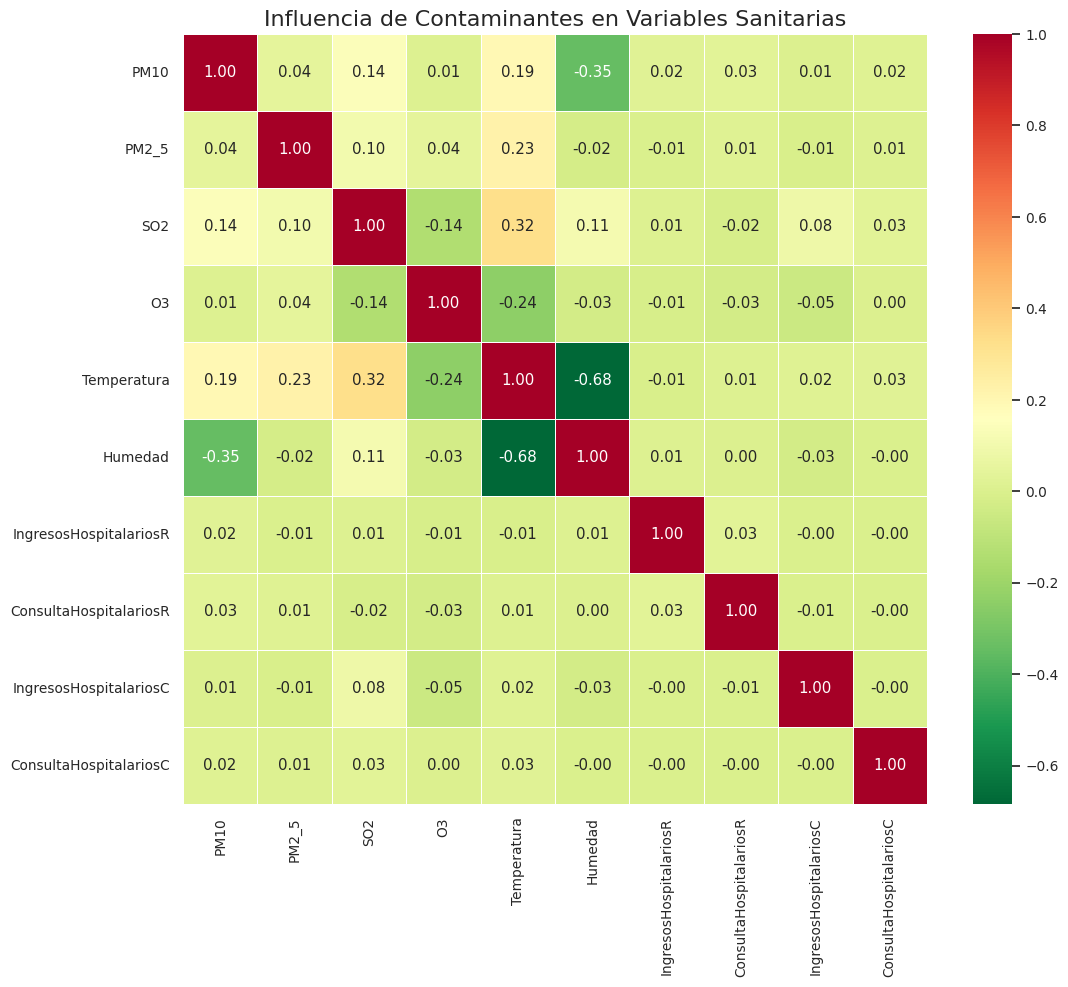

In [ ]:
variables_interes = [
    'PM10', 'PM2_5', 'SO2', 'O3',
    'Temperatura', 'Humedad',
    'IngresosHospitalariosR', 'ConsultaHospitalariosR',
    'IngresosHospitalariosC', 'ConsultaHospitalariosC'
]

corr = df[variables_interes].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='RdYlGn_r', fmt=".2f", linewidths=0.5)
plt.title('Influencia de Contaminantes en Variables Sanitarias', fontsize=16)
plt.show()

      3.9 Informe sobre el análisis del impacto de la calidad del aire en la salud

# 4. Ingeniería de atributos

*   imputacion de variables , reemplazar datos faltantes con ciertos valores.
*   Escala común, sin cambiar la forma de la distribución de los datos

Con el análisis exploratorio de datos se identificaron las variables mas importantes para la predicción de la tasa de salud:


In [ ]:

columnas_contaminantes = ['PM10', 'PM2_5', 'SO2', 'O3']

X = df[columnas_contaminantes]
imputer = SimpleImputer(strategy='median')
X_imputed_array = imputer.fit_transform(X)
X_final = pd.DataFrame(X_imputed_array, columns=columnas_contaminantes)
df[columnas_contaminantes] = X_final

In [ ]:
columnas_contaminantes = ['PM10', 'PM2_5', 'SO2', 'O3']

X = df[columnas_contaminantes]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_final = pd.DataFrame(X_scaled, columns=columnas_contaminantes)
print(X_final.head())

       PM10      PM2_5        SO2        O3
0 -3.313255 -14.199316   5.059615 -4.371283
1 -4.950495 -14.080040   4.673845 -0.810218
2 -3.859002 -13.786745   6.753093  4.045007
3 -1.130268 -13.336251  10.012732 -5.256704
4 -6.041988 -14.176592   0.902458 -9.218735


# 5. Entrenamiento y Testeo

      5.1 División de datos

In [ ]:
X = X_final
y = df['ClaseImpactoSalud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (52730, 4)
Test: (13183, 4)


      5.2 Entrenamiento y evaluación de modelos:

Los modelos elegidos fueron : k-Nearest Neighbors , Random forest , XGBoost, Redes neuronales,

        5.2.1 Knn

In [ ]:
# Modelo
knn = KNeighborsClassifier(
    n_neighbors=7,           # Número de vecinos
    weights='distance',      # Da más peso a los vecinos más cercanos
    metric='minkowski',      # Métrica estándar
    p=2,                     # p=2 es Euclidiana, p=1 es Manhattan
    algorithm='auto',        # Deja que sklearn decida el mejor algoritmo
    leaf_size=30             # Tamaño de hoja para árboles de búsqueda
)

# Entrenamiento
knn.fit(X_train, y_train)

# Predicción
y_pred_knn = knn.predict(X_test)

# Evaluación
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9988621709777744
              precision    recall  f1-score   support

       Buena       0.99      0.98      0.99       605
 Desconocido       1.00      1.00      1.00     12569
    Moderada       1.00      0.56      0.71         9

    accuracy                           1.00     13183
   macro avg       1.00      0.85      0.90     13183
weighted avg       1.00      1.00      1.00     13183



        5.2.2 Random forest

In [ ]:
# Modelo
rf = RandomForestClassifier(
    n_estimators=300,           # 300 para mayor estabilidad en el voto
    max_depth=12,               # Reducimos ligeramente para evitar que memorice ruidos
    min_samples_split=5,        # Requiere al menos 5 datos para crear una nueva rama
    min_samples_leaf=2,         # Asegura que cada "conclusión" final tenga al menos 2 casos
    max_features='sqrt',        # Explora una cantidad balanceada de contaminantes por árbol
    bootstrap=True,             # Activa el muestreo aleatorio para ganar diversidad
    oob_score=True,             # Permite validar el modelo con los datos que "sobraron"
    random_state=42,
    n_jobs=-1                   # Usa todos los núcleos de tu procesador
)

# Entrenamiento
rf.fit(X_train, y_train)

# Predicción
y_pred_rf = rf.predict(X_test)

# Evaluación
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9990897367822196
              precision    recall  f1-score   support

       Buena       1.00      0.98      0.99       605
 Desconocido       1.00      1.00      1.00     12569
    Moderada       1.00      0.89      0.94         9

    accuracy                           1.00     13183
   macro avg       1.00      0.96      0.98     13183
weighted avg       1.00      1.00      1.00     13183



        5.2.3 Xgboost

In [ ]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Modelo
xgb = XGBClassifier(
    n_estimators=500,           # Aumentamos los árboles pero bajamos el ritmo de aprendizaje
    learning_rate=0.05,         # Ritmo más lento para encontrar un mínimo global más preciso
    max_depth=5,                # Profundidad moderada para evitar memorizar ruido ambiental
    min_child_weight=2,         # Evita crear ramas para casos muy aislados
    gamma=0.2,                  # Penaliza divisiones que no aportan una reducción real de pérdida
    subsample=0.8,              # Usa el 80% de los datos para cada árbol (evita overfitting)
    colsample_bytree=0.8,       # Usa el 80% de los contaminantes por cada árbol
    reg_alpha=0.1,              # Regularización L1 (ayuda a manejar variables menos importantes)
    reg_lambda=1.5,             # Regularización L2 (mantiene los pesos de los parámetros estables)
    objective="multi:softmax",
    num_class=len(le.classes_),
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

# Entrenamiento
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

# Evaluacion
print("XGBoost Optimizado Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

XGBoost Optimizado Accuracy: 0.9986346051733292
              precision    recall  f1-score   support

       Buena       0.99      0.98      0.99       605
 Desconocido       1.00      1.00      1.00     12569
    Moderada       0.75      0.33      0.46         9

    accuracy                           1.00     13183
   macro avg       0.91      0.77      0.82     13183
weighted avg       1.00      1.00      1.00     13183



        5.2.4 Redes neuronales artificiales

In [ ]:
# Modelo
nn = MLPClassifier(
    hidden_layer_sizes=(100, 50), # Dos capas ocultas para captar patrones complejos
    activation='relu',            # Función de activación estándar
    solver='adam',                # Optimizador eficiente
    alpha=0.001,                  # Regularización para evitar sobreajuste
    learning_rate_init=0.001,     # Velocidad de aprendizaje inicial
    max_iter=1000,                # Aumentamos iteraciones para asegurar convergencia
    random_state=42,
    early_stopping=True,          # Detiene el entrenamiento si deja de mejorar (ahorra tiempo)
    validation_fraction=0.1       # Usa el 10% de los datos para autoevaluarse mientras entrena
)

# Entrenamiento
nn.fit(X_train, y_train)

# Predicción
y_pred = nn.predict(X_test)

# Precisión
accuracy = accuracy_score(y_test, y_pred)

print("Precisión del modelo de red neuronal:", accuracy)
print(classification_report(y_test, y_pred))

Precisión del modelo de red neuronal: 0.9984070393688842
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       605
           1       1.00      1.00      1.00     12569
           2       0.44      0.44      0.44         9

    accuracy                           1.00     13183
   macro avg       0.81      0.81      0.81     13183
weighted avg       1.00      1.00      1.00     13183



      5.3 Validación cruzada

In [ ]:
num_folds = 5

kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

models = {
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "Red Neuronal": MLPClassifier(max_iter=10000),
}
# Metricas
results = []
names = []
print('Metricas \n----------------------\n')
for name, model in models.items():
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f'{name}: {round(cv_results.mean(), 5)} ({round(cv_results.std(), 5)})')

Metricas 
----------------------

KNN: 0.99856 (0.00018)
RandomForest: 0.99875 (0.0003)
XGBoost: 0.99803 (0.00032)
Red Neuronal: 0.99843 (0.0003)


# 6. Optimización y selección de modelo

In [ ]:
params = [
    {   # KNN
        'KNN__n_neighbors': [3, 5, 7],
        'KNN__weights': ['uniform', 'distance'],
        'KNN__metric': ['euclidean', 'manhattan']
    },
    {   # RandomForest
        'RandomForest__n_estimators': [100, 200, 300],
        'RandomForest__max_depth': [None, 10, 20, 30],
        'RandomForest__min_samples_leaf': [1, 2, 4],
        'RandomForest__max_features': ['sqrt', 'log2']
    },
    {   # XGBoost
        'XGBoost__learning_rate': [0.01, 0.05, 0.1],
        'XGBoost__n_estimators': [100, 200, 500],
        'XGBoost__max_depth': [3, 5, 7],
        'XGBoost__subsample': [0.7, 0.8, 0.9],
        'XGBoost__colsample_bytree': [0.7, 0.8]
    },
    {   # Red Neuronal
        'Red Neuronal__hidden_layer_sizes': [(50,), (100,), (100,)],
        'Red Neuronal__activation': ['relu', 'logistic'],
        'Red Neuronal__alpha': [0.0001, 0.01, 0.1],
    }
]

result = []
best_models = []
# Búsqueda de hiperparámetros para cada modelo
for i, (name, model) in enumerate(models.items()):
    pipe = Pipeline([(name, model)])
    grid = GridSearchCV(pipe, params[i], cv=5, scoring='accuracy', n_jobs=-1, error_score='raise')
    grid.fit(X_train, y_train)

    best_model = (name, grid.best_estimator_)
    best_score = grid.best_score_
    best_models.append(best_model)
    result.append({'Modelo': name, 'Score': round(best_score, 5), 'Hiperparámetros': grid.best_params_})

    print(name + ':')
    print('Mejores parametros:', grid.best_params_)
    print('Precisión del entrenamiento:', round(grid.best_score_, 5))
    print('Precisión del test:', round(grid.score(X_test, y_test), 5))
    print('--------------------------------------------')

# Ordenamiento de los resultados
result = sorted(result, key=lambda k: k['Score'], reverse=True)
print('Orden de los modelos: ')
for res in result:
    print(res)

KNN:
Mejores parametros: {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 3, 'KNN__weights': 'distance'}
Precisión del entrenamiento: 0.99862
Precisión del test: 0.99879
--------------------------------------------
RandomForest:
Mejores parametros: {'RandomForest__max_depth': None, 'RandomForest__max_features': 'sqrt', 'RandomForest__min_samples_leaf': 1, 'RandomForest__n_estimators': 100}
Precisión del entrenamiento: 0.99875
Precisión del test: 0.99909
--------------------------------------------
XGBoost:
Mejores parametros: {'XGBoost__colsample_bytree': 0.8, 'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 5, 'XGBoost__n_estimators': 200, 'XGBoost__subsample': 0.8}
Precisión del entrenamiento: 0.99829
Precisión del test: 0.99871
--------------------------------------------
Red Neuronal:
Mejores parametros: {'Red Neuronal__activation': 'relu', 'Red Neuronal__alpha': 0.0001, 'Red Neuronal__hidden_layer_sizes': (100,)}
Precisión del entrenamiento: 0.99852
Precisión del test: 0.9987

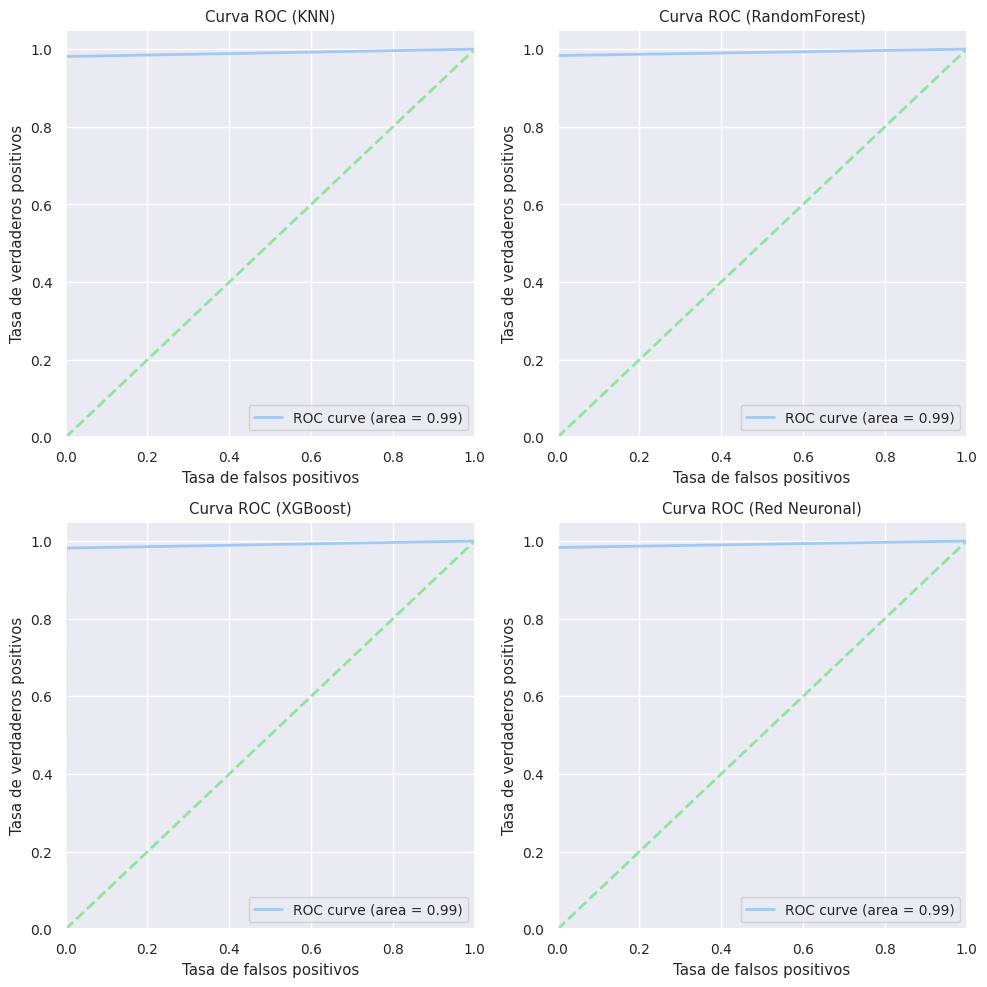

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
axs = axs.flatten()

for i, (name, model_obj) in enumerate(best_models):
    y_pred = model_obj.predict(X_test)

    if hasattr(model_obj, 'predict_proba'):
        y_pred_proba = model_obj.predict_proba(X_test)
        if not isinstance(y_test[0], (int, np.integer)):
            le = LabelEncoder()
            y_test_encoded = le.fit_transform(y_test)
            try:
                target_class_idx = list(le.classes_).index('Arriesgado')
            except ValueError:
                target_class_idx = 0
        else:
            y_test_encoded = y_test
            if 'le' in globals():
                 try:
                     target_class_idx = list(le.classes_).index('Arriesgado')
                 except ValueError:
                     target_class_idx = 0
            else:
                target_class_idx = 0

        if y_pred_proba.shape[1] > 2:
            fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba[:, target_class_idx], pos_label=target_class_idx)
        else:
            fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba[:, 1])

        roc_auc = auc(fpr, tpr)

        # Gráficas
        df_temp = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
        colors = sns.color_palette('pastel')
        sns.lineplot(x='fpr', y='tpr', data=df_temp, color=colors[0], lw=2, label='ROC curve (area = %0.2f)' % roc_auc, ax=axs[i])
        axs[i].plot([0, 1], [0, 1], color=colors[2], lw=2, linestyle='--')
        axs[i].set_xlim([0.0, 1.0])
        axs[i].set_ylim([0.0, 1.05])
        axs[i].set_xlabel('Tasa de falsos positivos')
        axs[i].set_ylabel('Tasa de verdaderos positivos')
        axs[i].set_title('Curva ROC (' + name + ')')
        axs[i].legend(loc="lower right")
    else:
        axs[i].set_title(f'ROC not available for {name}')
        axs[i].text(0.5, 0.5, 'Model does not support predict_proba', horizontalalignment='center', verticalalignment='center', transform=axs[i].transAxes)

plt.tight_layout()
plt.show()

# 7. Conclusión